# 📊 EDA – Dataset Final de Etiquetas MPLS

Este cuaderno realiza un análisis exploratorio utilizando el dataset final validado: `dataset_etiquetas_cajas_mpls_vfinal.csv`.

⚠️ **Este cuaderno ha sido actualizado para utilizar la versión final validada del dataset (`dataset_etiquetas_cajas_mpls_vfinal.csv`)**.

## 🧾 Descripción del Proyecto y Objetivos del EDA

### 🗂️ Nombre del Proyecto
**Validación automática de etiquetas de red mediante visión computacional - Cajas MPLS**

### 📑 Descripción del Dataset
Este dataset contiene más de 1000 registros de etiquetas utilizadas en cajas MPLS de redes de fibra óptica. Cada etiqueta está compuesta por varios campos codificados, como ciudad, nodo concentrador, nodo estándar, ruta, código de caja y color de buffer. Los datos fueron extraídos de sistemas internos de la empresa y reflejan configuraciones reales en campo.

### 🎯 Objetivos del EDA

- Entender la estructura y distribución de las variables contenidas en las etiquetas.
- Identificar patrones frecuentes, posibles errores o inconsistencias en la información codificada.
- Detectar valores atípicos o anomalías que podrían afectar el entrenamiento de un modelo de IA.
- Proveer recomendaciones de limpieza y preprocesamiento para el diseño de un sistema automático de validación de etiquetas.

### 📚 1. Importación de Librerías
Las siguientes librerías son utilizadas a lo largo del análisis:

```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
```


### 📚 1. Importación de Librerías

A continuación se importan las librerías necesarias para el análisis exploratorio de datos. Cada una cumple un propósito específico en el flujo de trabajo:

```python
import pandas as pd        # Permite cargar, manipular y analizar datos tabulares (estructurados como DataFrame).
import seaborn as sns      # Librería especializada en visualización estadística; usada para gráficos de barras, heatmaps, etc.
import matplotlib.pyplot as plt  # Complementa a Seaborn y permite configurar gráficos detalladamente (títulos, tamaños, etiquetas).
```


In [1]:
# 📥 Cargar librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 📂 Cargar dataset limpio
df = pd.read_csv('/content/dataset_etiquetas_cajas_mpls_vfinal.csv')

In [2]:
# 👀 Primeras y últimas filas
print("🔍 Primeras filas:")
display(df.head())

print("🔍 Últimas filas:")
display(df.tail())

🔍 Primeras filas:


,N,Etiqueta,TS,ciudad,nodo_concentrador,nodo_estandar,nodo_backup,ruta,caja_codigo,color_buffer,tipo_ruta,clase,detalle_validacion
0,1.0,UIO-Gosseal (A)-Whymper (E)(B)/Whymper (E)(A)-...,UIO,UIO,Gosseal (A),Whymper (E)(B),Whymper (E)(A),F02,PE16B,CAF,ruta_completa,1,Etiqueta valida
1,2.0,UIO-Gosseal (A)-Whymper (E)(A)/Whymper (E)(B)-...,UIO,UIO,Gosseal (A),Whymper (E)(A),Whymper (E)(B),F02,PE15B,CAF,ruta_completa,1,Etiqueta valida
2,3.0,UIO-Gosseal (A)-Whymper (E)(B)/Whymper (E)(A)-...,UIO,UIO,Gosseal (A),Whymper (E)(B),Whymper (E)(A),F02,PE14B,CAF,ruta_completa,1,Etiqueta valida
3,4.0,UIO-Gosseal (A)-Whymper (E)(A)/Whymper (E)(B)-...,UIO,UIO,Gosseal (A),Whymper (E)(A),Whymper (E)(B),F02,PE13B,CAF,ruta_completa,1,Etiqueta valida
4,5.0,UIO-Gosseal (A)-Whymper (E)(B)/Whymper (E)(A)-...,UIO,UIO,Gosseal (A),Whymper (E)(B),Whymper (E)(A),F02,PE12B,VER,ruta_completa,1,Etiqueta valida


🔍 Últimas filas:


,N,Etiqueta,TS,ciudad,nodo_concentrador,nodo_estandar,nodo_backup,ruta,caja_codigo,color_buffer,tipo_ruta,clase,detalle_validacion
813,NaN,UIO-Centro-???/N/A-F56-PQ12X-ROSA,UIO,UIO,Centro,???,NaN,F56,PQ12X,ROSA,ruta_no_aplica,0,Ejemplo sintetico incorrecto
814,NaN,CUE-Centro-123/N/A-F11--NEGROX,CUE,CUE,Centro,123,NaN,F11,NaN,NEGROX,ruta_no_aplica,0,Ejemplo sintetico incorrecto
815,NaN,UIO-???-/N/A-F98-12345-,UIO,UIO,???,NaN,NaN,F98,12345,NaN,ruta_no_aplica,0,Ejemplo sintetico incorrecto
816,NaN,CUE--???/N/A-F62-PQ12X-,CUE,CUE,NaN,???,NaN,F62,PQ12X,NaN,ruta_no_aplica,0,Ejemplo sintetico incorrecto
817,NaN,UIO-Centro-???/N/A-F60-PQ12X-ROSA,UIO,UIO,Centro,???,NaN,F60,PQ12X,ROSA,ruta_no_aplica,0,Ejemplo sintetico incorrecto


In [ ]:
# ℹ️ Información general del dataset
df.info()
print(f"📐 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   N                  1000 non-null   int64 
 1   Etiqueta           1000 non-null   object
 2   TS                 1000 non-null   object
 3   ciudad             723 non-null    object
 4   nodo_concentrador  722 non-null    object
 5   nodo_estandar      723 non-null    object
 6   nodo_backup        722 non-null    object
 7   ruta               723 non-null    object
 8   caja_codigo        723 non-null    object
 9   color_buffer       723 non-null    object
dtypes: int64(1), object(9)
memory usage: 78.3+ KB
📐 Dimensiones: 1000 filas × 10 columnas


In [3]:
# ⚠️ Verificación de valores faltantes
print("🔎 Valores nulos por columna:")
print(df.isnull().sum())

🔎 Valores nulos por columna:
N                     200
Etiqueta                0
TS                      0
ciudad                  0
nodo_concentrador      46
nodo_estandar          45
nodo_backup           347
ruta                    0
caja_codigo            37
color_buffer           50
tipo_ruta               0
clase                   0
detalle_validacion      0
dtype: int64


In [4]:
# 📊 Estadísticas básicas de variables
df.describe(include='all')

,N,Etiqueta,TS,ciudad,nodo_concentrador,nodo_estandar,nodo_backup,ruta,caja_codigo,color_buffer,tipo_ruta,clase,detalle_validacion
count,618.000000,818,818,818,772,773,471,818,781,768,818,818.000000,818
unique,NaN,818,4,9,15,35,23,82,164,16,2,NaN,2
top,NaN,UIO-Centro-???/N/A-F60-PQ12X-ROSA,UIO,UIO,Parrales (A),Parrales (A),Parrales (A),F01,12345,CAF,ruta_completa,NaN,Etiqueta valida
freq,NaN,1,315,315,132,60,60,280,55,69,493,NaN,618
mean,498.027508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.755501,NaN
std,357.095578,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.430053,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,155.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
50%,309.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
75%,845.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN


## 2️⃣ Análisis Univariado

### 🎨 Colores de buffer de la caja (`color_buffer`)

In [5]:
# 📊 Frecuencia absoluta y relativa – color_buffer
print("📊 Frecuencia absoluta:")
print(df['color_buffer'].value_counts())

print("\n📊 Frecuencia relativa (%):")
print((df['color_buffer'].value_counts(normalize=True) * 100).round(2))

📊 Frecuencia absoluta:
color_buffer
CAF       69
VER       67
AMA       55
GRI       53
NEG       52
ROS       52
CEL       52
VIO       50
XXX       46
ROJ       43
BLA       43
AZU       41
NAR       41
NEGROX    37
ROSA      34
BLANCO    33
Name: count, dtype: int64

📊 Frecuencia relativa (%):
color_buffer
CAF       8.98
VER       8.72
AMA       7.16
GRI       6.90
NEG       6.77
ROS       6.77
CEL       6.77
VIO       6.51
XXX       5.99
ROJ       5.60
BLA       5.60
AZU       5.34
NAR       5.34
NEGROX    4.82
ROSA      4.43
BLANCO    4.30
Name: proportion, dtype: float64


/tmp/ipython-input-1430674829.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='color_buffer', order=df['color_buffer'].value_counts().index, palette='Set2')


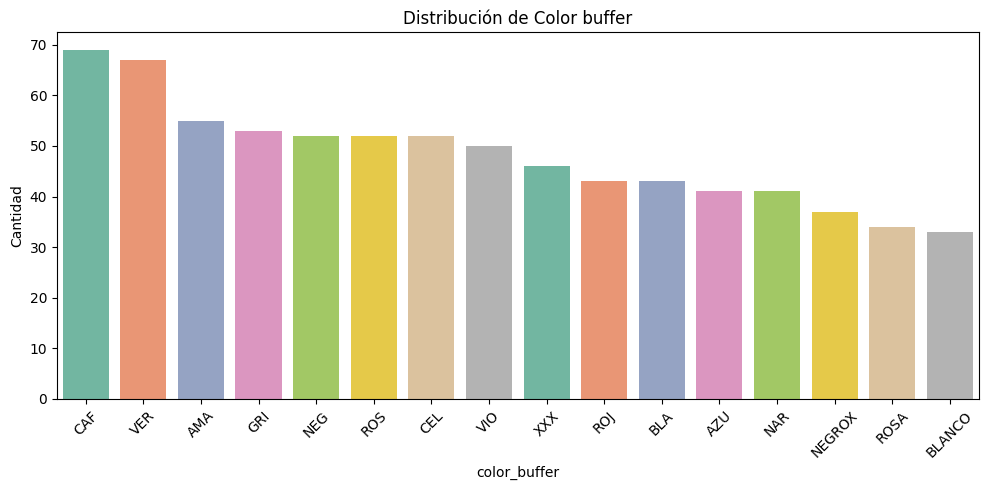

In [6]:
# 📈 Gráfico de barras – color_buffer
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='color_buffer', order=df['color_buffer'].value_counts().index, palette='Set2')
plt.title("Distribución de Color buffer")
plt.xlabel("color_buffer")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🏙️ Ciudad de origen de la caja (`ciudad`)

In [7]:
# 📊 Frecuencia absoluta y relativa – ciudad
print("📊 Frecuencia absoluta:")
print(df['ciudad'].value_counts())

print("\n📊 Frecuencia relativa (%):")
print((df['ciudad'].value_counts(normalize=True) * 100).round(2))

📊 Frecuencia absoluta:
ciudad
UIO    315
CUE    131
GYE    122
JIP    120
STA     48
PVO     40
PTL     24
SCR     12
MOT      6
Name: count, dtype: int64

📊 Frecuencia relativa (%):
ciudad
UIO    38.51
CUE    16.01
GYE    14.91
JIP    14.67
STA     5.87
PVO     4.89
PTL     2.93
SCR     1.47
MOT     0.73
Name: proportion, dtype: float64


/tmp/ipython-input-1898641568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ciudad', order=df['ciudad'].value_counts().index, palette='Set2')


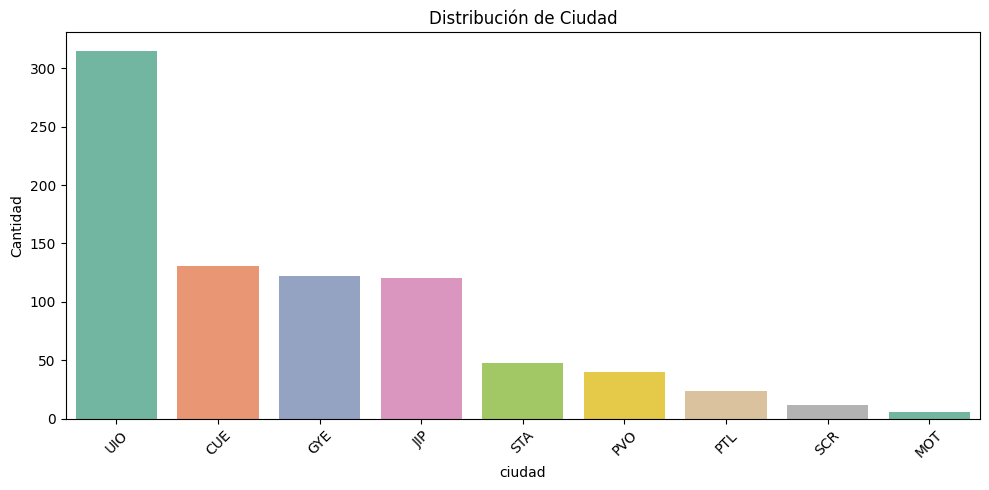

In [8]:
# 📈 Gráfico de barras – ciudad
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='ciudad', order=df['ciudad'].value_counts().index, palette='Set2')
plt.title("Distribución de Ciudad")
plt.xlabel("ciudad")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📡 Nodo concentrador principal (`nodo_concentrador`)

In [9]:
# 📊 Frecuencia absoluta y relativa – nodo_concentrador
print("📊 Frecuencia absoluta:")
print(df['nodo_concentrador'].value_counts())

print("\n📊 Frecuencia relativa (%):")
print((df['nodo_concentrador'].value_counts(normalize=True) * 100).round(2))

📊 Frecuencia absoluta:
nodo_concentrador
Parrales (A)        132
Sur 2 (A)           111
Portoviejo (A)       88
Armenia (A)          63
Bellavista (A)       55
Centro               53
NODO-X               53
???                  48
Kennedy 1(A)         41
Gosseal (A)          40
Bodega (E)           24
Puerto Lopez (A)     24
Centro 1(A)          22
Borromoni (A)        12
Manta SDH (A)         6
Name: count, dtype: int64

📊 Frecuencia relativa (%):
nodo_concentrador
Parrales (A)        17.10
Sur 2 (A)           14.38
Portoviejo (A)      11.40
Armenia (A)          8.16
Bellavista (A)       7.12
Centro               6.87
NODO-X               6.87
???                  6.22
Kennedy 1(A)         5.31
Gosseal (A)          5.18
Bodega (E)           3.11
Puerto Lopez (A)     3.11
Centro 1(A)          2.85
Borromoni (A)        1.55
Manta SDH (A)        0.78
Name: proportion, dtype: float64


/tmp/ipython-input-3836129883.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='nodo_concentrador', order=df['nodo_concentrador'].value_counts().index, palette='Set2')


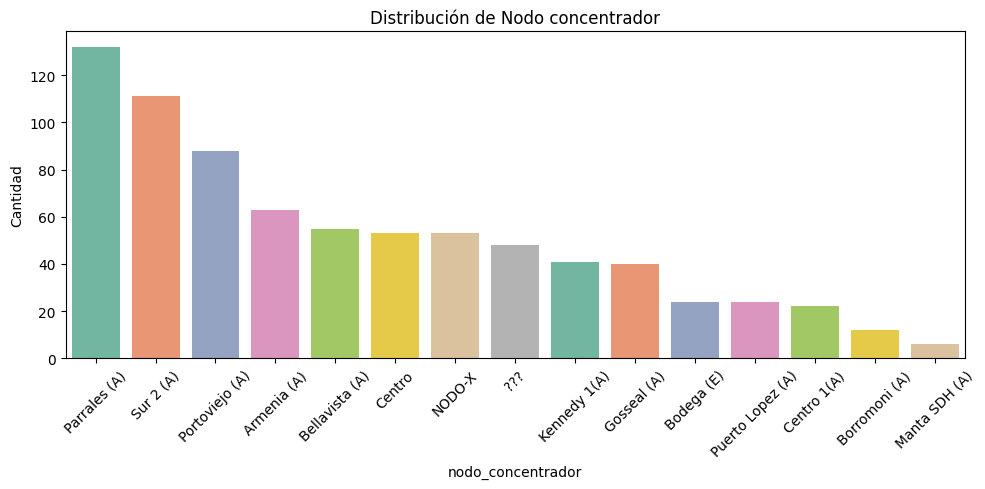

In [10]:
# 📈 Gráfico de barras – nodo_concentrador
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='nodo_concentrador', order=df['nodo_concentrador'].value_counts().index, palette='Set2')
plt.title("Distribución de Nodo concentrador")
plt.xlabel("nodo_concentrador")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🧭 Nodo estándar asignado (`nodo_estandar`)

In [11]:
# 📊 Frecuencia absoluta y relativa – nodo_estandar
print("📊 Frecuencia absoluta:")
print(df['nodo_estandar'].value_counts())

print("\n📊 Frecuencia relativa (%):")
print((df['nodo_estandar'].value_counts(normalize=True) * 100).round(2))

📊 Frecuencia absoluta:
nodo_estandar
Parrales (A)                      60
Jipijapa SDH (A)                  60
123                               58
Final                             54
Pintag (E)                        44
???                               43
Sur 2 (A)                         29
Roldos (E)                        24
Ayacucho (E)                      24
Puerto Lopez (A)                  24
Calle 3 (E)                       24
Nogales (E)                       24
Control Sur (E)                   22
Alborada 3(E)                     21
Mall del Rio (E)                  21
San Alejo (E)(B)                  20
San Alejo (E)(A)                  20
Alborada 1(E)                     20
Recreo (E)                        20
Calle H (E)                       16
Ayacucho (E)(B)                   12
Sucre (E)                         12
Ayacucho (E)(A)                   12
Gualleturo (E)                    12
Tababela (E)                      12
El Valle (E)                      12
V

/tmp/ipython-input-1641211870.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='nodo_estandar', order=df['nodo_estandar'].value_counts().index, palette='Set2')


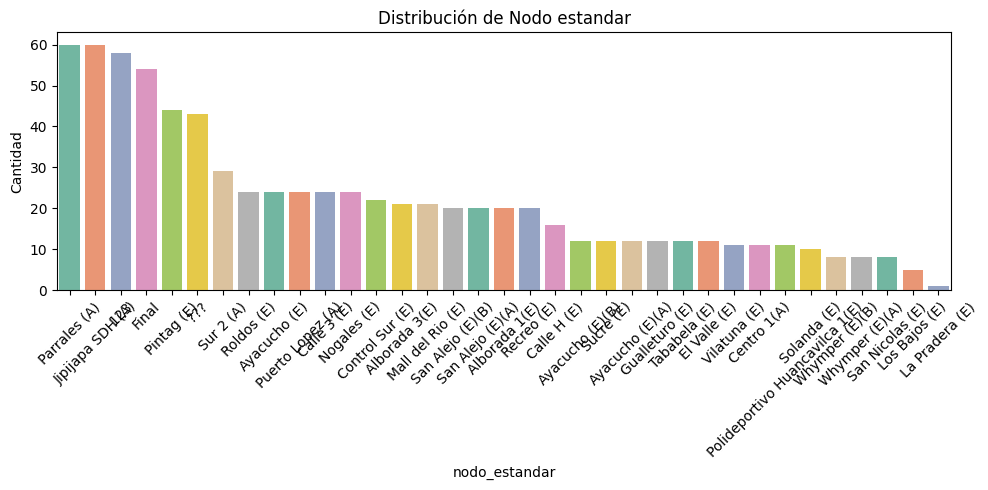

In [12]:
# 📈 Gráfico de barras – nodo_estandar
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='nodo_estandar', order=df['nodo_estandar'].value_counts().index, palette='Set2')
plt.title("Distribución de Nodo estandar")
plt.xlabel("nodo_estandar")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🛡️ Nodo de respaldo (backup) (`nodo_backup`)

In [13]:
# 📊 Frecuencia absoluta y relativa – nodo_backup
print("📊 Frecuencia absoluta:")
print(df['nodo_backup'].value_counts())

print("\n📊 Frecuencia relativa (%):")
print((df['nodo_backup'].value_counts(normalize=True) * 100).round(2))

📊 Frecuencia absoluta:
nodo_backup
Parrales (A)                      60
Jipijapa SDH (A)                  60
???                               31
Sur 2 (A)                         30
456                               28
Mall del Rio (E)                  22
Alborada 1(E)                     21
Control Sur (E)                   21
San Alejo (E)(B)                  20
San Alejo (E)(A)                  20
Alborada 3(E)                     20
Recreo (E)                        20
Pintag (E)                        19
BackupX                           19
Ayacucho (E)(A)                   12
Ayacucho (E)(B)                   12
Centro 1(A)                       11
Polideportivo Huancavilca 1(E)    11
Solanda (E)                        9
San Nicolas (E)                    8
Whymper (E)(B)                     8
Whymper (E)(A)                     8
San Andres (E)                     1
Name: count, dtype: int64

📊 Frecuencia relativa (%):
nodo_backup
Parrales (A)                      12.74
Jipijapa

/tmp/ipython-input-1288289376.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='nodo_backup', order=df['nodo_backup'].value_counts().index, palette='Set2')


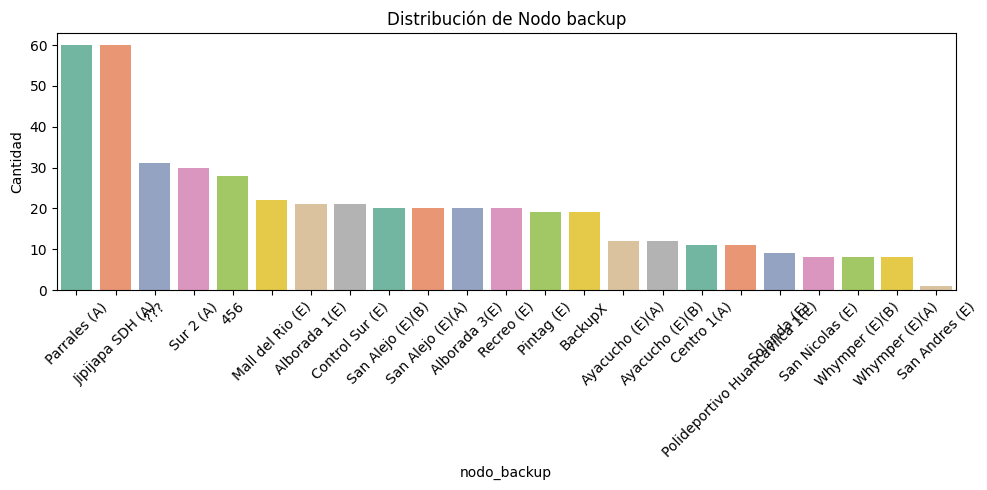

In [14]:
# 📈 Gráfico de barras – nodo_backup
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='nodo_backup', order=df['nodo_backup'].value_counts().index, palette='Set2')
plt.title("Distribución de Nodo backup")
plt.xlabel("nodo_backup")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🛤️ Ruta asignada (FXX) (`ruta`)

In [15]:
# 📊 Frecuencia absoluta y relativa – ruta
print("📊 Frecuencia absoluta:")
print(df['ruta'].value_counts())

print("\n📊 Frecuencia relativa (%):")
print((df['ruta'].value_counts(normalize=True) * 100).round(2))

📊 Frecuencia absoluta:
ruta
F01    280
F02    143
F04     99
F03     95
F67      7
      ... 
F71      1
F93      1
F48      1
F13      1
F95      1
Name: count, Length: 82, dtype: int64

📊 Frecuencia relativa (%):
ruta
F01    34.23
F02    17.48
F04    12.10
F03    11.61
F67     0.86
       ...  
F71     0.12
F93     0.12
F48     0.12
F13     0.12
F95     0.12
Name: proportion, Length: 82, dtype: float64


/tmp/ipython-input-3954400994.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ruta', order=df['ruta'].value_counts().index, palette='Set2')


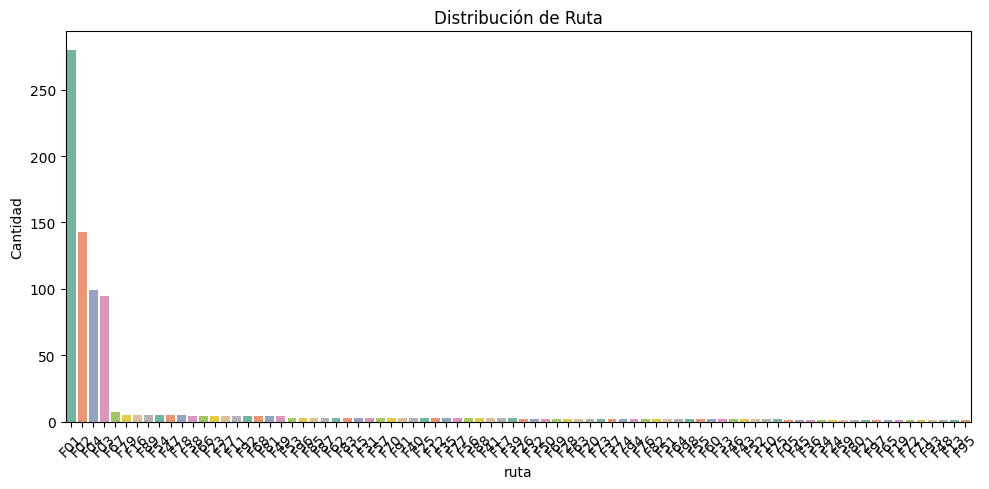

In [16]:
# 📈 Gráfico de barras – ruta
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='ruta', order=df['ruta'].value_counts().index, palette='Set2')
plt.title("Distribución de Ruta")
plt.xlabel("ruta")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📦 Código de caja MPLS (`caja_codigo`)

In [17]:
# 📊 Frecuencia absoluta y relativa – caja_codigo
print("📊 Frecuencia absoluta:")
print(df['caja_codigo'].value_counts())

print("\n📊 Frecuencia relativa (%):")
print((df['caja_codigo'].value_counts(normalize=True) * 100).round(2))

📊 Frecuencia absoluta:
caja_codigo
12345    55
PQ12X    37
CAXXA    37
PE-99    34
PC09B    16
         ..
P12B      1
PC47B     1
PC41B     1
PC42B     1
PC43B     1
Name: count, Length: 164, dtype: int64

📊 Frecuencia relativa (%):
caja_codigo
12345    7.04
PQ12X    4.74
CAXXA    4.74
PE-99    4.35
PC09B    2.05
         ... 
P12B     0.13
PC47B    0.13
PC41B    0.13
PC42B    0.13
PC43B    0.13
Name: proportion, Length: 164, dtype: float64


/tmp/ipython-input-1681122590.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='caja_codigo', order=df['caja_codigo'].value_counts().index, palette='Set2')


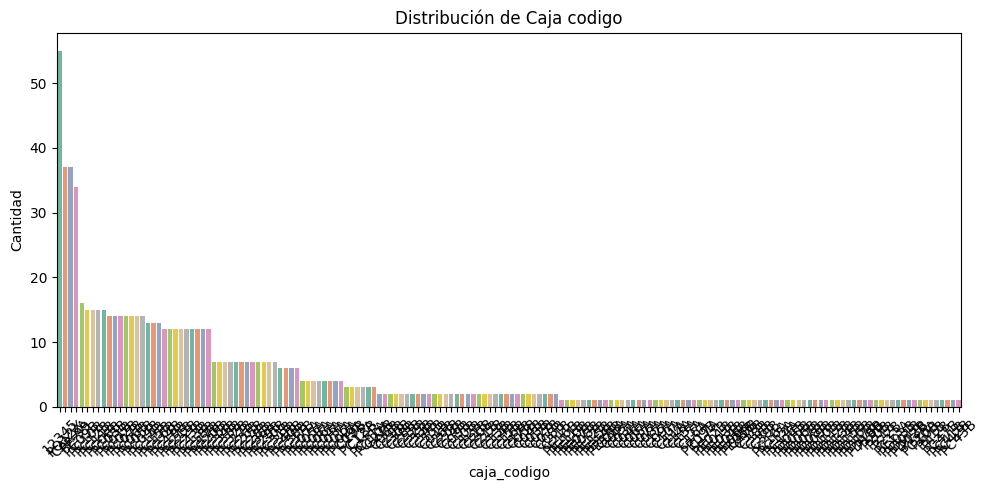

In [18]:
# 📈 Gráfico de barras – caja_codigo
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='caja_codigo', order=df['caja_codigo'].value_counts().index, palette='Set2')
plt.title("Distribución de Caja codigo")
plt.xlabel("caja_codigo")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3️⃣ Análisis Bivariado

En esta sección se exploran relaciones entre variables categóricas del dataset para identificar patrones conjuntos o dependencias. Aunque no contamos aún con una variable objetivo numérica, podemos analizar combinaciones relevantes que podrían ser útiles para el diseño del modelo de validación de etiquetas.

### 🎨 `color_buffer` vs 🏙️ `ciudad`

In [19]:
# 📊 Conteo conjunto de color y ciudad
pd.crosstab(df['color_buffer'], df['ciudad'])

ciudad,CUE,GYE,JIP,MOT,PTL,PVO,SCR,STA,UIO
color_buffer,,,,,,,,,
AMA,9,6,12,0,2,4,0,2,20
AZU,0,2,0,0,2,0,3,8,26
BLA,6,4,12,0,2,4,0,2,13
BLANCO,17,8,0,0,0,0,0,0,8
CAF,6,6,12,3,2,4,3,8,25
CEL,3,7,12,0,2,4,0,2,22
GRI,6,6,12,1,2,4,0,2,20
NAR,0,2,0,0,2,0,3,8,26
NEG,6,6,12,0,2,4,0,2,20


/tmp/ipython-input-3540212131.py:8: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


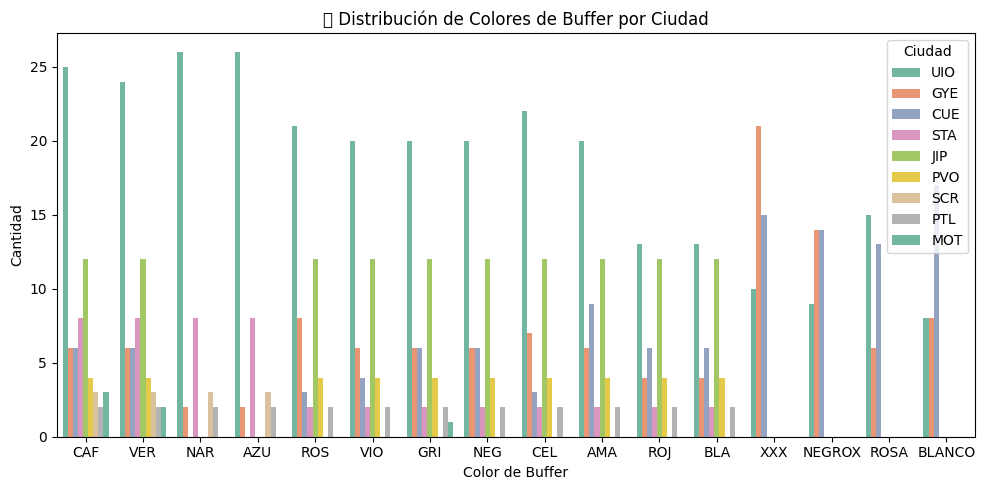

In [20]:
# 📈 Gráfico: color_buffer según ciudad
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='color_buffer', hue='ciudad', palette='Set2')
plt.title("🎨 Distribución de Colores de Buffer por Ciudad")
plt.xlabel("Color de Buffer")
plt.ylabel("Cantidad")
plt.legend(title="Ciudad")
plt.tight_layout()
plt.show()

### 🎨 `color_buffer` vs 🛤️ `ruta`

/tmp/ipython-input-1743198024.py:9: UserWarning: Glyph 128740 (\N{RAILWAY TRACK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128740 (\N{RAILWAY TRACK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


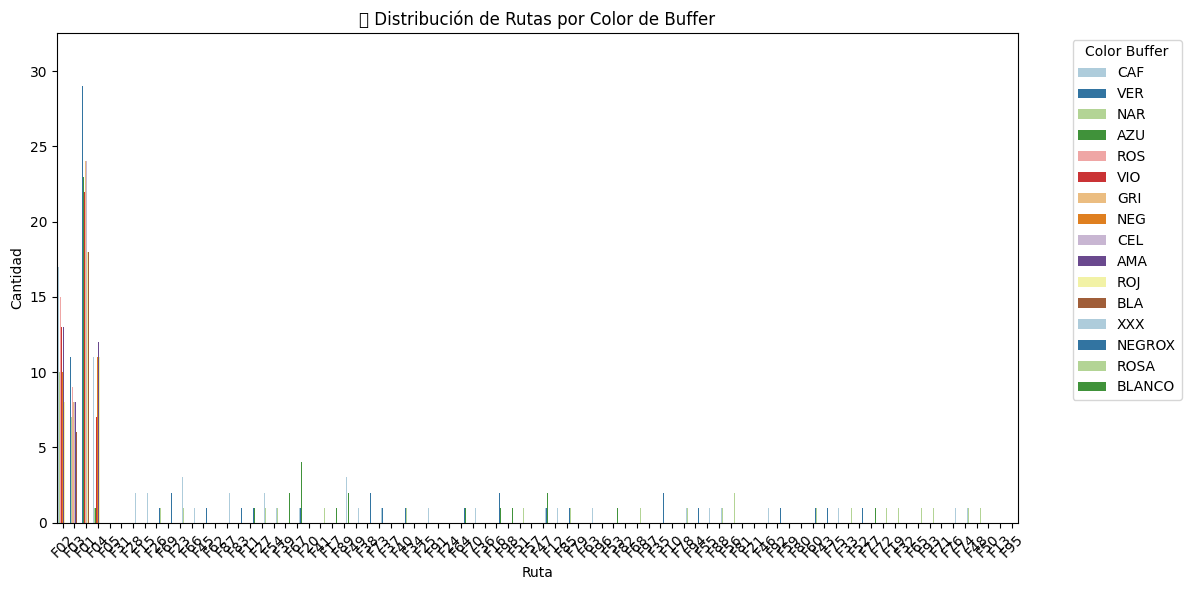

In [21]:
# 📈 Gráfico: color_buffer según ruta
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='ruta', hue='color_buffer', palette='Paired')
plt.title("🛤️ Distribución de Rutas por Color de Buffer")
plt.xlabel("Ruta")
plt.ylabel("Cantidad")
plt.legend(title="Color Buffer", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🏙️ `ciudad` vs 📡 `nodo_concentrador`

/tmp/ipython-input-586181146.py:10: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


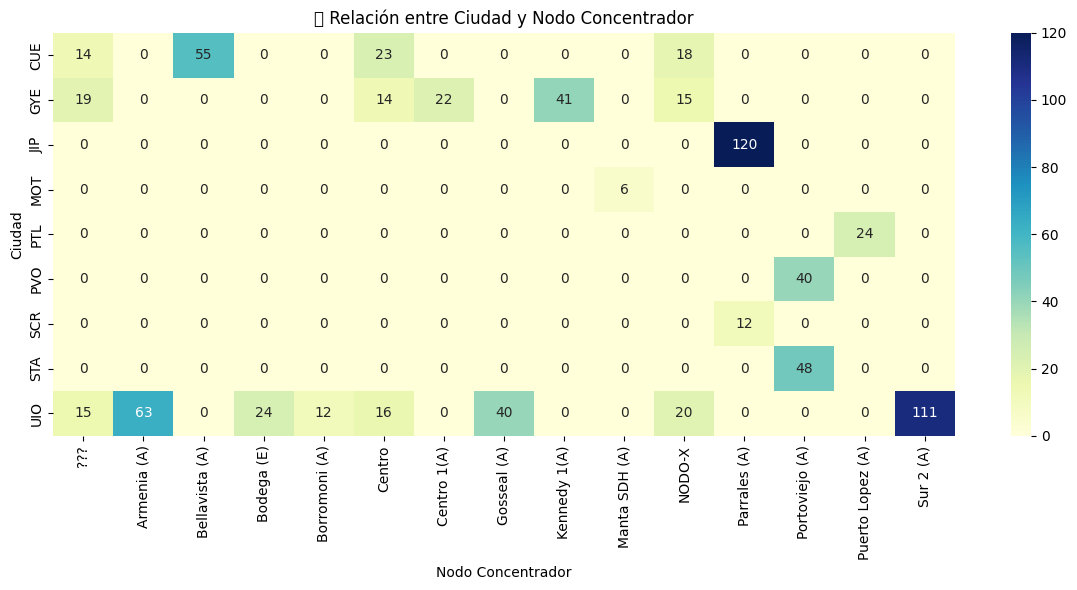

In [22]:
# 📊 Tabla cruzada ciudad vs nodo concentrador
tabla = pd.crosstab(df['ciudad'], df['nodo_concentrador'])

# 🔥 Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(tabla, cmap="YlGnBu", annot=True, fmt='d')
plt.title("📡 Relación entre Ciudad y Nodo Concentrador")
plt.xlabel("Nodo Concentrador")
plt.ylabel("Ciudad")
plt.tight_layout()
plt.show()

### 🧭 `nodo_estandar` vs 🛡️ `nodo_backup`

/tmp/ipython-input-3721719861.py:10: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


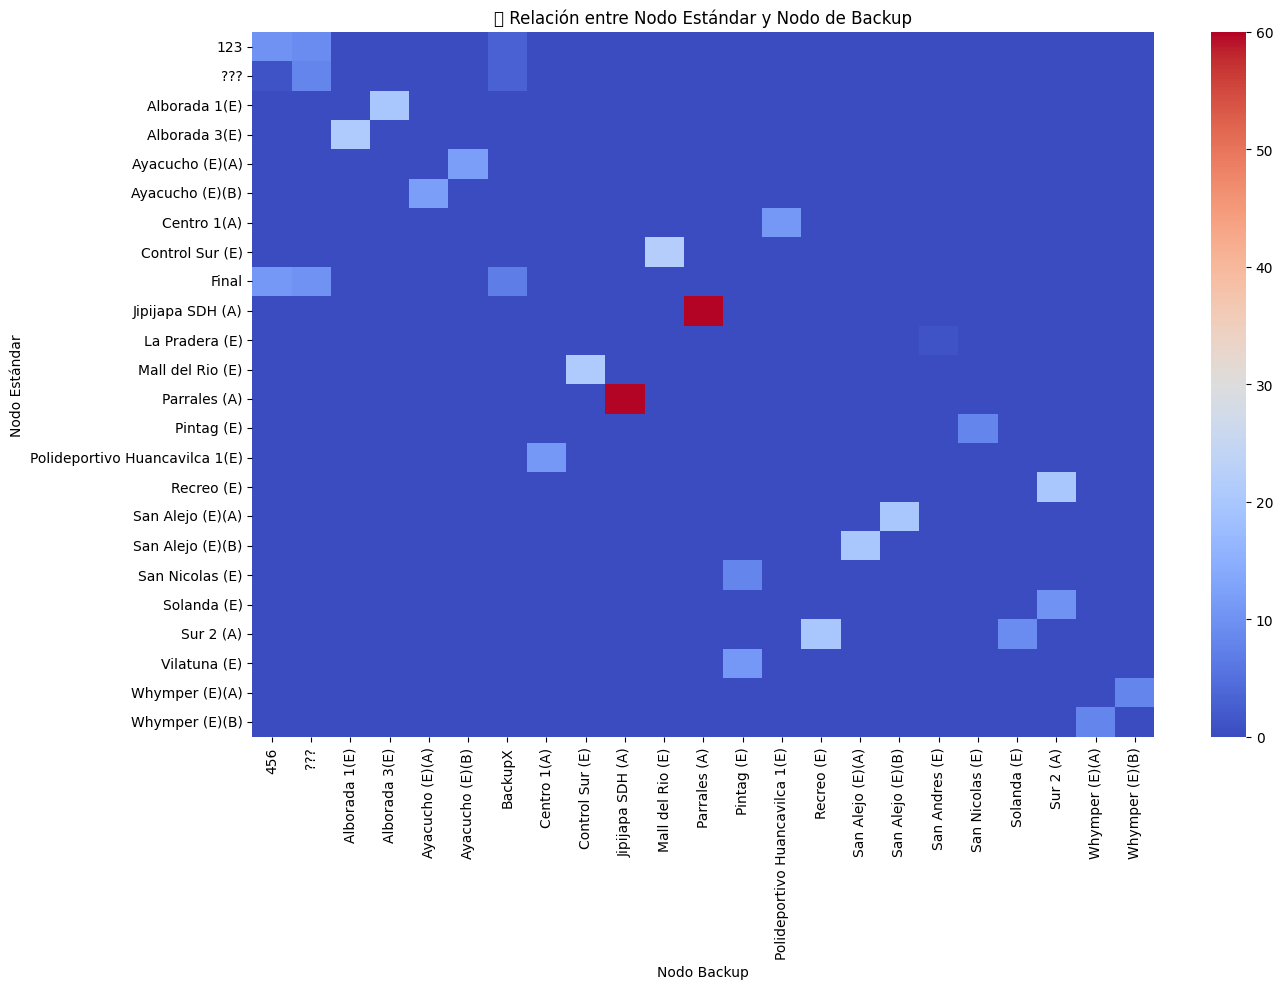

In [23]:
# 📊 Tabla cruzada nodo estándar vs backup
tabla2 = pd.crosstab(df['nodo_estandar'], df['nodo_backup'])

# 🔥 Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(tabla2, cmap="coolwarm", annot=False)
plt.title("🧭 Relación entre Nodo Estándar y Nodo de Backup")
plt.xlabel("Nodo Backup")
plt.ylabel("Nodo Estándar")
plt.tight_layout()
plt.show()

## 4️⃣ Análisis Multivariado

El análisis multivariado permite visualizar combinaciones de más de dos variables a la vez para descubrir patrones complejos, asociaciones cruzadas y segmentos de interés dentro del dataset. Aunque las variables son categóricas, podemos usar gráficos segmentados y agrupaciones para representar insights multidimensionales.

### 🎨 `color_buffer` según 🏙️ `ciudad` y 🛤️ `ruta` (Gráfico agrupado)

/tmp/ipython-input-3022628240.py:9: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


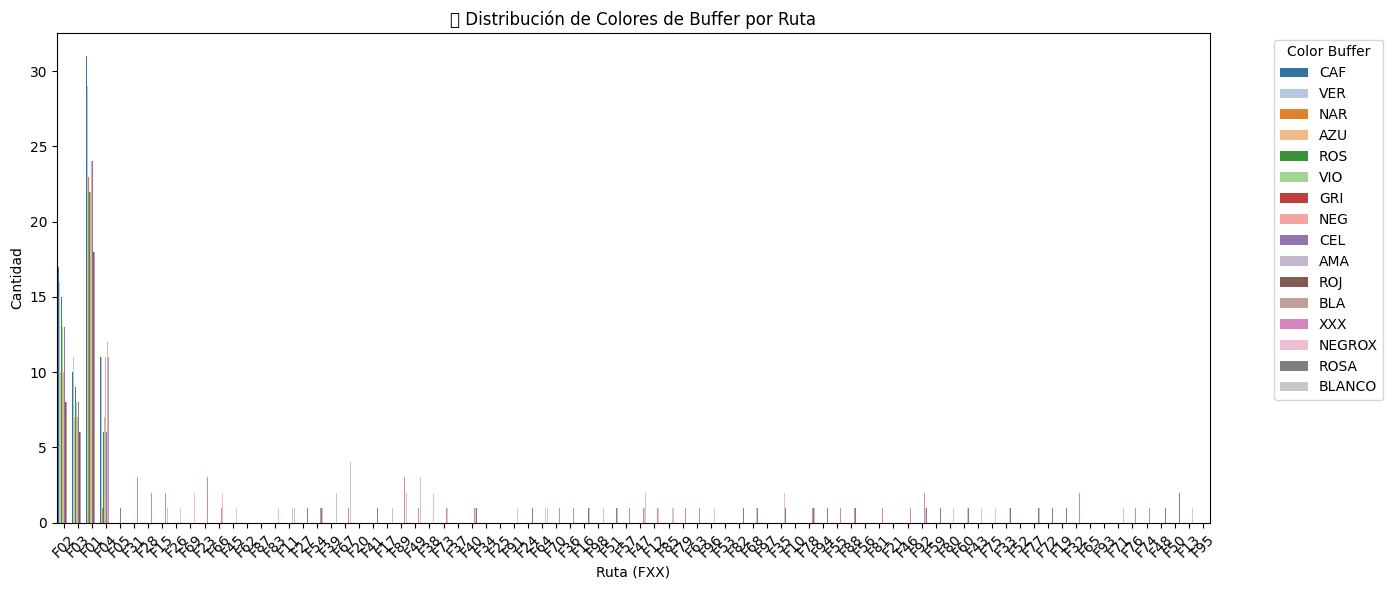

In [24]:
# 📊 Conteo agrupado: ciudad, ruta y color
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='ruta', hue='color_buffer', palette='tab20', dodge=True)
plt.title("🎨 Distribución de Colores de Buffer por Ruta")
plt.xlabel("Ruta (FXX)")
plt.ylabel("Cantidad")
plt.legend(title="Color Buffer", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🏙️ `ciudad` + 📡 `nodo_concentrador` + 🎨 `color_buffer`

/tmp/ipython-input-2614144881.py:10: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


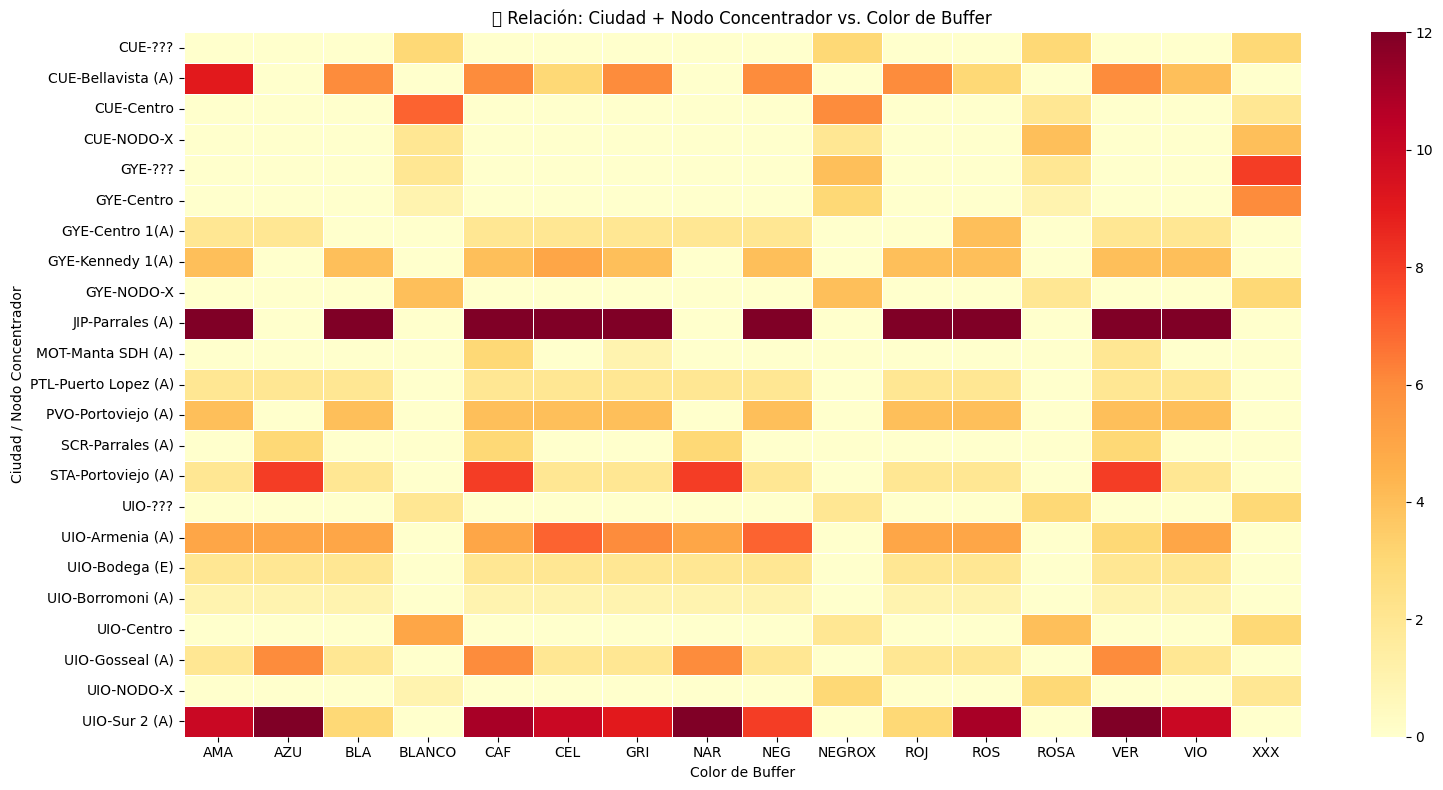

In [25]:
# 💡 Agrupación por ciudad, nodo y color
tabla3 = pd.crosstab([df['ciudad'], df['nodo_concentrador']], df['color_buffer'])

# 🔥 Heatmap multivariado
plt.figure(figsize=(16, 8))
sns.heatmap(tabla3, cmap="YlOrRd", linewidths=.5)
plt.title("📊 Relación: Ciudad + Nodo Concentrador vs. Color de Buffer")
plt.xlabel("Color de Buffer")
plt.ylabel("Ciudad / Nodo Concentrador")
plt.tight_layout()
plt.show()

### 📦 Distribución de `caja_codigo` por 🏙️ `ciudad` y 🛤️ `ruta`

/tmp/ipython-input-3900611070.py:9: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


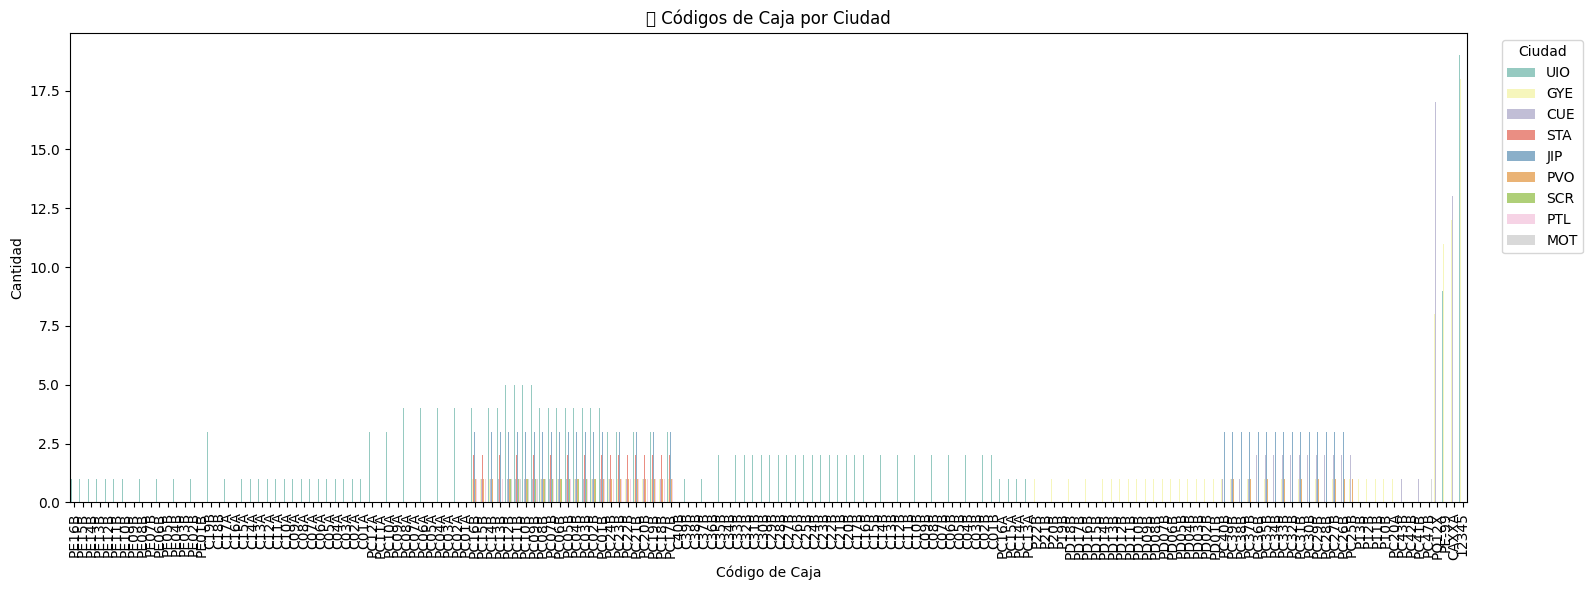

In [26]:
# ⚙️ Conteo de cajas por ciudad y ruta
plt.figure(figsize=(16, 6))
sns.countplot(data=df, x='caja_codigo', hue='ciudad', palette='Set3')
plt.title("📦 Códigos de Caja por Ciudad")
plt.xlabel("Código de Caja")
plt.ylabel("Cantidad")
plt.legend(title="Ciudad", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5️⃣ Identificación de Patrones y Anomalías

Esta sección tiene como objetivo identificar valores atípicos, distribuciones anómalas y posibles inconsistencias en los datos, lo cual es crucial para el preprocesamiento y entrenamiento robusto de modelos de IA. Aunque no se cuenta con una variable continua para aplicar métodos estadísticos clásicos, se pueden detectar anomalías en la frecuencia y estructura de los datos categóricos.

### ❌ Validación de colores fuera de estándar

In [27]:
# 🎨 Lista oficial de colores válidos
colores_validos = ['ROJ', 'BLA', 'CAF', 'VER', 'NAR', 'AZU',
                   'ROS', 'VIO', 'GRI', 'NEG', 'CEL', 'AMA']

# 🔎 Colores que no están en la lista oficial
colores_encontrados = df['color_buffer'].dropna().unique()
colores_invalidos = [c for c in colores_encontrados if c not in colores_validos]

print("🎯 Colores encontrados:", colores_encontrados)
print("❌ Colores no válidos:", colores_invalidos)


🎯 Colores encontrados: ['CAF' 'VER' 'NAR' 'AZU' 'ROS' 'VIO' 'GRI' 'NEG' 'CEL' 'AMA' 'ROJ' 'BLA'
 'XXX' 'NEGROX' 'ROSA' 'BLANCO']
❌ Colores no válidos: ['XXX', 'NEGROX', 'ROSA', 'BLANCO']


### 📉 Rutas atípicas o con baja frecuencia

In [28]:
# 🔎 Frecuencia de rutas
frecuencias_rutas = df['ruta'].value_counts()
print(frecuencias_rutas.tail(10))  # Mostrar las menos comunes


ruta
F21    1
F97    1
F65    1
F19    1
F72    1
F71    1
F93    1
F48    1
F13    1
F95    1
Name: count, dtype: int64


### 🔁 Detección de combinaciones duplicadas sospechosas (`caja_codigo` + `color_buffer`)

In [29]:
# 🚨 Buscar duplicados exactos de combinaciones
duplicados = df.duplicated(subset=['caja_codigo', 'color_buffer'], keep=False)
df[duplicados].sort_values(by='caja_codigo')


,N,Etiqueta,TS,ciudad,nodo_concentrador,nodo_estandar,nodo_backup,ruta,caja_codigo,color_buffer,tipo_ruta,clase,detalle_validacion
696,NaN,CUE-???-123/-F12-12345-NEGROX,CUE,CUE,???,123,NaN,F12,12345,NEGROX,ruta_completa,0,Ejemplo sintetico incorrecto
783,NaN,GYE-???-???/N/A-F78-12345-BLANCO,GYE,GYE,???,???,NaN,F78,12345,BLANCO,ruta_no_aplica,0,Ejemplo sintetico incorrecto
782,NaN,CUE-Centro-Final/N/A-F49-12345-BLANCO,CUE,CUE,Centro,Final,NaN,F49,12345,BLANCO,ruta_no_aplica,0,Ejemplo sintetico incorrecto
731,NaN,GYE--123/N/A-F92-12345-NEGROX,GYE,GYE,NaN,123,NaN,F92,12345,NEGROX,ruta_no_aplica,0,Ejemplo sintetico incorrecto
776,NaN,GYE-???-/N/A-F67-12345-XXX,GYE,GYE,???,NaN,NaN,F67,12345,XXX,ruta_no_aplica,0,Ejemplo sintetico incorrecto
...,...,...,...,...,...,...,...,...,...,...,...,...,...
803,NaN,UIO-NODO-X-123/N/A-F55--,UIO,UIO,NODO-X,123,NaN,F55,NaN,NaN,ruta_no_aplica,0,Ejemplo sintetico incorrecto
804,NaN,CUE-NODO-X-???/N/A-F13--NEGROX,CUE,CUE,NODO-X,???,NaN,F13,NaN,NEGROX,ruta_no_aplica,0,Ejemplo sintetico incorrecto
807,NaN,UIO-NODO-X-/N/A-F78--,UIO,UIO,NODO-X,NaN,NaN,F78,NaN,NaN,ruta_no_aplica,0,Ejemplo sintetico incorrecto
811,NaN,CUE-NODO-X-123/N/A-F95--,CUE,CUE,NODO-X,123,NaN,F95,NaN,NaN,ruta_no_aplica,0,Ejemplo sintetico incorrecto


### 🧯 Identificación de outliers en cantidad por ciudad

/tmp/ipython-input-569378276.py:9: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


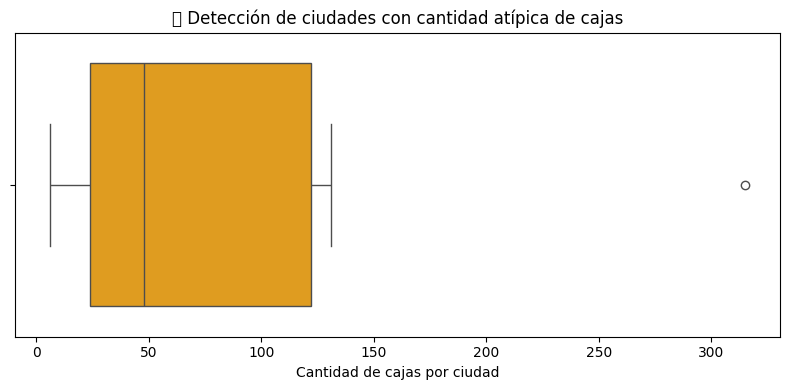

In [30]:
# 📦 Conteo de cajas por ciudad
conteo_ciudad = df['ciudad'].value_counts()

# 📈 Visualizar posibles outliers en frecuencias
plt.figure(figsize=(8, 4))
sns.boxplot(x=conteo_ciudad.values, color='orange')
plt.title("📦 Detección de ciudades con cantidad atípica de cajas")
plt.xlabel("Cantidad de cajas por ciudad")
plt.tight_layout()
plt.show()


## 6️⃣ Conclusiones e Insights

Esta sección resume los hallazgos clave del análisis exploratorio. Se detallan los patrones más importantes observados en los datos, las implicaciones para el desarrollo del modelo de IA, y se proponen recomendaciones de preprocesamiento y próximos pasos.

### 📌 Hallazgos principales

1. **Predominio de ciertos colores de buffer**: Algunos colores como `CAF`, `AZU` y `VER` son los más frecuentes, mientras que otros aparecen muy poco, lo cual puede influir en el balance de clases para validación automática.

2. **Concentración geográfica**: La mayoría de las cajas se concentran en una sola ciudad (`UIO`), lo que podría generar un sesgo en el modelo si se entrena solo con estos datos.

3. **Alta repetición de nodos concentradores y estándar**: Se identifican nodos que aparecen significativamente más que otros, lo cual podría usarse como feature de importancia o como señal de redundancia.

4. **Combinaciones duplicadas entre caja y color**: Se detectaron combinaciones exactas que podrían indicar errores en el etiquetado físico.

5. **Pocas rutas atípicas**: La mayoría de las rutas están bien distribuidas, pero algunas aparecen muy pocas veces y podrían ser casos extremos o errores de captura.

6. **Distribuciones multivariadas claras**: Se identificaron patrones al cruzar ciudad, ruta y color, útiles para clasificación supervisada y validación automatizada.



### 🛠️ Recomendaciones de Preprocesamiento

- Validar manualmente las combinaciones duplicadas de `caja_codigo` + `color_buffer`.
- Etiquetar registros con colores no válidos para su revisión o exclusión.
- Balancear clases si se construirá un modelo supervisado con `color_buffer` como objetivo.
- Considerar codificación de variables categóricas (`One-Hot` o `Label Encoding`).
- Filtrar outliers o rutas atípicas si afectan la generalización del modelo.



### 🚀 Próximos pasos

- Iniciar el diseño del modelo de clasificación para validación automática de etiquetas.
- Evaluar algoritmos candidatos (Random Forest, SVM, Redes Neuronales, etc.).
- Integrar un pipeline de preprocesamiento y entrenamiento.
- Considerar despliegue futuro con visión computacional si se integran imágenes físicas de las etiquetas.



## 🗂️ Anexo: Dataset utilizado

**Nombre del archivo:** `dataset_etiquetas_cajas_mpls.csv`  
**Ubicación:** Repositorio del proyecto > `data/samples/`

### 📑 Descripción

Este archivo contiene más de 1000 registros reales de etiquetas MPLS extraídas de las cajas de red utilizadas en proyectos de fibra óptica. Cada registro representa una etiqueta codificada con información como:

- Ciudad (`ciudad`)
- Nodo concentrador (`nodo_concentrador`)
- Nodo estándar (`nodo_estandar`)
- Nodo backup (`nodo_backup`)
- Ruta (`ruta`)
- Código de caja (`caja_codigo`)
- Color del buffer (`color_buffer`)

### 🔍 Fuente

Los datos fueron proporcionados por el equipo de operaciones de campo de la empresa de telecomunicaciones que participa en este proyecto. Se extrajeron directamente desde sus sistemas internos de gestión de infraestructura.

### 🧠 Contexto

Las etiquetas son utilizadas en campo para la identificación física de cajas de red MPLS. El análisis exploratorio de estos datos permite establecer la base para desarrollar un modelo de IA capaz de validar automáticamente dichas etiquetas, detectar errores y reducir inconsistencias operativas.
